# Time Series Forecasting Using Transformer

Here the notebook follow the [repo: Time-Series-Forecasting](rezaAdinepour/Time-Series-Forecasting) to run time-series forecasting using transformer.

We also:

* Add early stopping
* Showing how loss varies.

The code is simple; just one layer but show good performance for time-series forecasting.

In [1]:
import sys
# Update this path to the directory containing model.py
sys.path.append('/content/drive/MyDrive/Colab-Notebooks/Time-Series-Forecasting/')

In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
!ls /content/drive/MyDrive/Colab-Notebooks/Time-Series-Forecasting/

Mounted at /content/drive
data  src  Untitled0.ipynb


## Data

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("/content/drive/MyDrive/Colab-Notebooks/Time-Series-Forecasting/data/facebook.csv")
df.shape

(160679, 21)

In [5]:
df.head()

,date,minute,label,high,low,open,close,average,volume,notional,...,rsi,long,exit_long,short,exit_short,long_pnl,short_pnl,total_pnl,long_labels,short_labels
0,2019-04-01,09:30,09:30 AM,168.000,167.52,167.925,167.82,167.775,9294.0,1559300.720,...,NaN,NaN,167.925,NaN,167.805,NaN,NaN,0.0,NaN,NaN
1,2019-04-01,09:31,09:31 AM,168.190,167.76,167.760,168.19,167.908,863.0,144904.500,...,100.000000,NaN,167.925,NaN,167.805,NaN,NaN,0.0,NaN,NaN
2,2019-04-01,09:32,09:32 AM,168.630,168.36,168.390,168.36,168.490,2707.0,456101.680,...,100.000000,NaN,167.925,NaN,167.805,NaN,NaN,0.0,NaN,NaN
3,2019-04-01,09:33,09:33 AM,168.135,167.94,168.135,168.04,168.132,5503.0,925229.920,...,46.468401,NaN,167.925,NaN,167.805,NaN,NaN,0.0,NaN,NaN
4,2019-04-01,09:34,09:34 AM,168.200,168.00,168.045,168.01,168.189,15236.0,2562520.845,...,43.215212,NaN,167.925,NaN,167.805,NaN,NaN,0.0,NaN,NaN


### logarithmic normalization

In [5]:
# open
open = df["open"].fillna(method="ffill")
open = np.array(open)
open_logreturn = np.diff(np.log(open))
open_csum_logreturn = open_logreturn.cumsum()

# close
close = df["close"].fillna(method="ffill")
close = np.array(close)
close_logreturn = np.diff(np.log(close))
close_csum_logreturn = close_logreturn.cumsum()

# average
average = df["average"].fillna(method="ffill")
average = np.array(average)
average_logreturn = np.diff(np.log(average))
average_csum_logreturn = average_logreturn.cumsum()

/tmp/ipykernel_13684/2399476197.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  open = df["open"].fillna(method="ffill")
/tmp/ipykernel_13684/2399476197.py:8: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  close = df["close"].fillna(method="ffill")
/tmp/ipykernel_13684/2399476197.py:14: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  average = df["average"].fillna(method="ffill")
/tmp/ipykernel_13684/2399476197.py:16: RuntimeWarning: invalid value encountered in log
  average_logreturn = np.diff(np.log(average))


### Visualization

Text(0, 0.5, 'average Price')

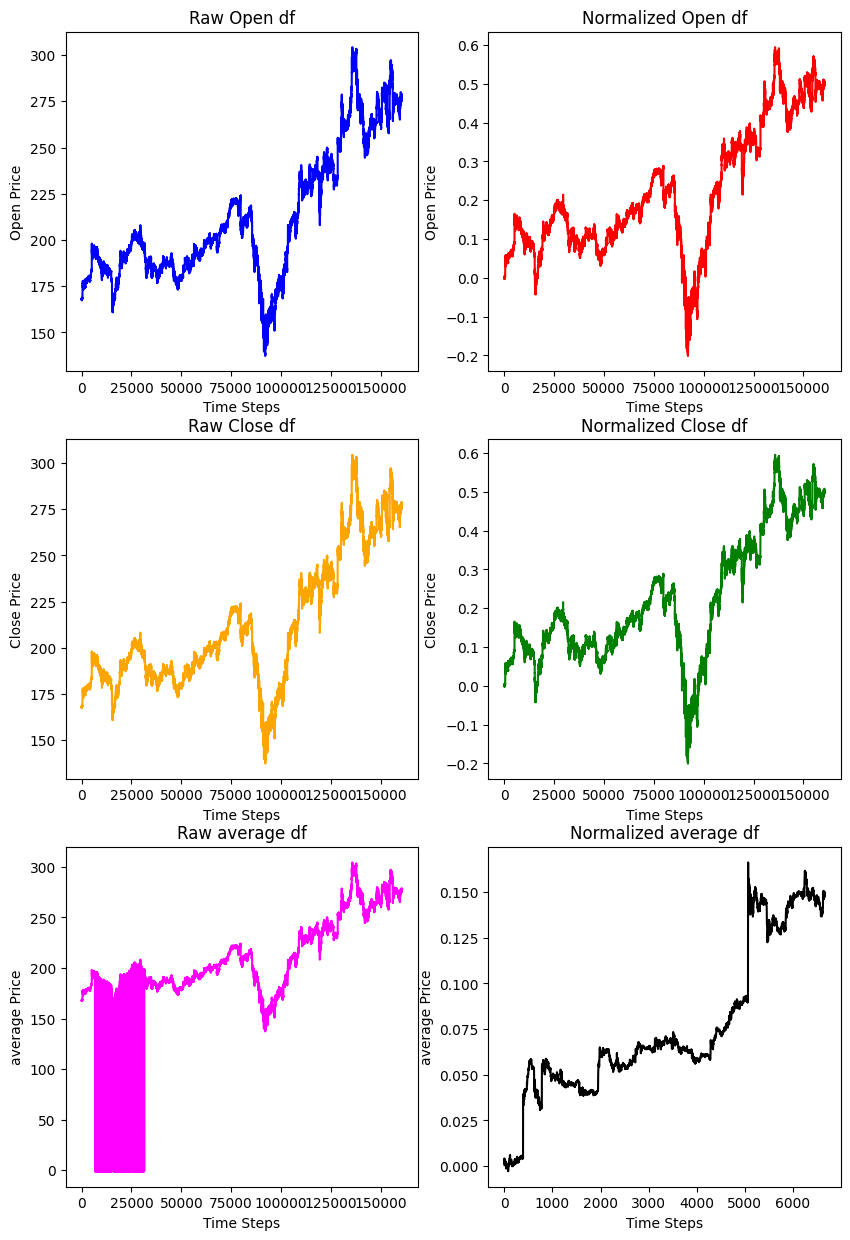

In [8]:
fig = plt.figure(figsize=(10, 15))

plt.subplot(3, 2, 1)
plt.plot(open, color="blue")
plt.title("Raw Open df")
plt.xlabel("Time Steps")
plt.ylabel("Open Price")

plt.subplot(3, 2, 2)
plt.plot(open_csum_logreturn, color="red")
plt.title("Normalized Open df")
plt.xlabel("Time Steps")
plt.ylabel("Open Price")

plt.subplot(3, 2, 3)
plt.plot(close, color="orange")
plt.title("Raw Close df")
plt.xlabel("Time Steps")
plt.ylabel("Close Price")

plt.subplot(3, 2, 4)
plt.plot(close_csum_logreturn, color="green")
plt.title("Normalized Close df")
plt.xlabel("Time Steps")
plt.ylabel("Close Price")

plt.subplot(3, 2, 5)
plt.plot(average, color="magenta")
plt.title("Raw average df")
plt.xlabel("Time Steps")
plt.ylabel("average Price")

plt.subplot(3, 2, 6)
plt.plot(average_csum_logreturn, color="black")
plt.title("Normalized average df")
plt.xlabel("Time Steps")
plt.ylabel("average Price")

In [6]:
import torch
import torch.nn as nn

import time

from src.model_helper import transformer
from src.data_helper import split_data

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [7]:
input_window = 10 # number of input steps
output_window = 1 #  number of prediction steps, in this model its fixed to one

train_data, val_data = split_data(
    close_logreturn,
    split=0.6,
    input_window=input_window,
    output_window=output_window
) # 60% train, 40% test split

model = transformer().to(device)

/content/drive/MyDrive/Colab-Notebooks/Time-Series-Forecasting/src/data_helper.py:15: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  return torch.FloatTensor(inout_seq)
/content/drive/MyDrive/Colab-Notebooks/Time-Series-Forecasting/src/model_helper.py:30: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.transformer_encoder = nn.TransformerEncoder(self.encoder_layer, num_layers=num_layers)


In [8]:
criterion = nn.MSELoss()
lr = 0.00005
max_epochs = 100

batch_size = 250

optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, 1.0, gamma=0.95)

In [9]:
def get_batch(source, i, batch_size):
    seq_len = min(batch_size, len(source) - 1 - i)
    data = source[i:i+seq_len]
    input = torch.stack(torch.stack([item[0] for item in data]).chunk(input_window, 1))
    target = torch.stack(torch.stack([item[1] for item in data]).chunk(input_window, 1))
    return input, target

def train(train_data):
    model.train()
    total_loss = 0.0
    start_time = time.time()

    for batch, i in enumerate(range(0, len(train_data) - 1, batch_size)):
        data, targets = get_batch(train_data, i, batch_size)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, targets)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 0.7)
        optimizer.step()

        total_loss += loss.item()
        log_interval = int(len(train_data) / batch_size / 5)
        if(batch % log_interval == 0 and batch > 0):
            cur_loss = total_loss / log_interval
            elapsed = time.time() - start_time
            # print("| epoch {:3d} | {:5d}/{:5d} batches | "
            #       "lr {:02.10f} | {:5.2f} ms | "
            #       "loss {:5.7f}".format(
            #         epoch, batch, len(train_data) // batch_size, scheduler.get_lr()[0],
            #         elapsed * 1000 / log_interval,
            #         cur_loss))
            total_loss = 0
            start_time = time.time()

def evaluate(eval_model, data_source):
    eval_model.eval()
    total_loss = 0.0
    eval_batch_size = 1000
    with torch.no_grad():
        for i in range(0, len(data_source) - 1, eval_batch_size):
            data, targets = get_batch(data_source, i, eval_batch_size)
            output = eval_model(data)
            total_loss += len(data[0])* criterion(output, targets).cpu().item()
    return total_loss / len(data_source)

In [10]:
from src.helper import EarlyStopping

In [12]:
early_stopping = EarlyStopping(patience=15, min_delta=0.02)

train_losses, val_losses = [], []
for epoch in range(1, max_epochs + 1):
    epoch_start_time = time.time()
    train(train_data)

    train_loss = evaluate(model, train_data)
    val_loss = evaluate(model, val_data)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print("| epoch {:3d} | time: {:5.2f}s | train loss: {:5.7f} | valid loss: {:5.7f}".format(epoch, (time.time() - epoch_start_time), train_loss, val_loss))

    early_stopping(val_loss, model)
    # here we implement early stopping, when val_loss > min_val_loss for 2% and wait for {patient} steps still,
    # we stop to avoid overfitting.

    # 3. Check if the flag was tripped
    if early_stopping.early_stop:
        print("Early stopping triggered! Training stopped.")
        break

    scheduler.step()

print("-" * 80)
print("| end of epoch {:3d} | time: {:5.2f}s | valid loss: {:5.7f}".format(min(epoch, max_epochs), (time.time() - epoch_start_time), val_loss))
print("-" * 80)

| epoch   1 | time:  4.28s | train loss: 0.0675034 | valid loss: 0.1489549
| epoch   2 | time:  4.19s | train loss: 0.0459336 | valid loss: 0.1117217
| epoch   3 | time:  4.00s | train loss: 0.0294971 | valid loss: 0.0819806
| epoch   4 | time:  4.28s | train loss: 0.0228208 | valid loss: 0.0677414
| epoch   5 | time:  4.11s | train loss: 0.0208564 | valid loss: 0.0618676
| epoch   6 | time:  4.02s | train loss: 0.0178332 | valid loss: 0.0539432
| epoch   7 | time:  4.30s | train loss: 0.0156155 | valid loss: 0.0476523
| epoch   8 | time:  4.21s | train loss: 0.0124149 | valid loss: 0.0395683
| epoch   9 | time:  4.05s | train loss: 0.0111745 | valid loss: 0.0354777
| epoch  10 | time:  4.22s | train loss: 0.0079853 | valid loss: 0.0276285
| epoch  11 | time:  4.19s | train loss: 0.0062171 | valid loss: 0.0227480
| epoch  12 | time:  4.02s | train loss: 0.0051676 | valid loss: 0.0195335
| epoch  13 | time:  4.20s | train loss: 0.0046434 | valid loss: 0.0175548
| epoch  14 | time:  4.16

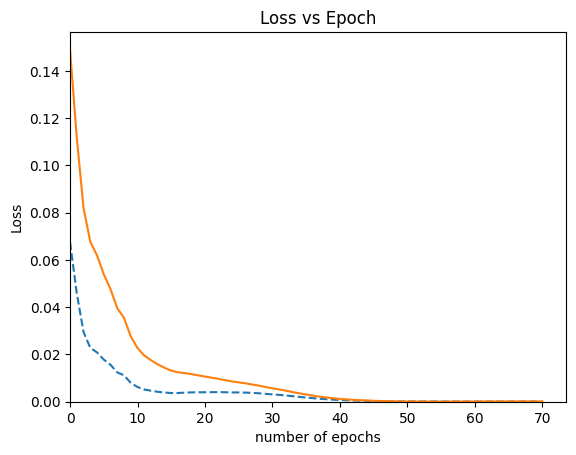

In [13]:
plt.plot(range(len(train_losses)), train_losses, label="train loss", linestyle="dashed")
plt.plot(range(len(val_losses)), val_losses, label="val loss")

plt.title("Loss vs Epoch")
plt.xlabel("number of epochs")
plt.ylabel("Loss")
plt.xlim(left=0)
plt.ylim(bottom=0)
plt.show()

## Validation

In [14]:
def forecast_seq(model, sequences):

    start_timer = time.time()
    model.eval()
    forecast_seq = torch.Tensor(0)
    actual = torch.Tensor(0)
    with torch.no_grad():
        for i in range(0, len(sequences) - 1):
            data, target = get_batch(sequences, i, 1)
            output = model(data)
            forecast_seq = torch.cat((forecast_seq, output[-1].view(-1).cpu()), 0)
            actual = torch.cat((actual, target[-1].view(-1).cpu()), 0)
    timed = time.time()-start_timer
    print(f"{timed} sec")

    return forecast_seq, actual

In [15]:
test_result, truth = forecast_seq(model, val_data)

87.65832018852234 sec


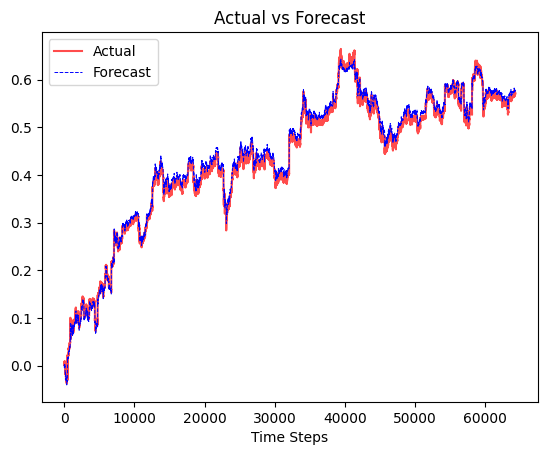

In [16]:
plt.plot(truth, color="red", alpha=0.7)
plt.plot(test_result, color="blue", linestyle="dashed", linewidth=0.7)
plt.title("Actual vs Forecast")
plt.legend(["Actual", "Forecast"])
plt.xlabel("Time Steps")
plt.show()

## Save Model and Load Model

In [19]:
%cd /content/drive/MyDrive/Colab-Notebooks/Time-Series-Forecasting/model
torch.save(model.state_dict(), "time_forecasting_transformer.pth")

/content/drive/MyDrive/Colab-Notebooks/Time-Series-Forecasting/model


In [20]:
%cd /content/drive/MyDrive/Colab-Notebooks/Time-Series-Forecasting/model

model_val = transformer()
model_val.load_state_dict(torch.load("time_forecasting_transformer.pth"))
model_val.to(device)

/content/drive/MyDrive/Colab-Notebooks/Time-Series-Forecasting/model


/content/drive/MyDrive/Colab-Notebooks/Time-Series-Forecasting/src/model_helper.py:30: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.transformer_encoder = nn.TransformerEncoder(self.encoder_layer, num_layers=num_layers)


transformer(
  (pos_encoder): PositionalEncoding()
  (encoder_layer): TransformerEncoderLayer(
    (self_attn): MultiheadAttention(
      (out_proj): NonDynamicallyQuantizableLinear(in_features=250, out_features=250, bias=True)
    )
    (linear1): Linear(in_features=250, out_features=2048, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
    (linear2): Linear(in_features=2048, out_features=250, bias=True)
    (norm1): LayerNorm((250,), eps=1e-05, elementwise_affine=True)
    (norm2): LayerNorm((250,), eps=1e-05, elementwise_affine=True)
    (dropout1): Dropout(p=0.1, inplace=False)
    (dropout2): Dropout(p=0.1, inplace=False)
  )
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0): TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=250, out_features=250, bias=True)
        )
        (linear1): Linear(in_features=250, out_features=2048, bias=True)
        (dropout): Dro

## Other Datasets

### Boeing data

In [21]:
df2 = pd.read_csv("/content/drive/MyDrive/Colab-Notebooks/Time-Series-Forecasting/data/boeing.csv")
close2 = df2["close"].fillna(method = "ffill")
close2 = np.array(close2)
logreturn2 = np.diff(np.log(close2))

/tmp/ipykernel_13684/1466301839.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  close2 = df2["close"].fillna(method = "ffill")


In [22]:
train_data2, val_data2 = split_data(logreturn2, split=0.6)
test2_eval = evaluate(model_val, val_data2)
print(f"boeing test loss: {test2_eval :.5f}")

boeing test loss: 0.00004


86.46977543830872 sec


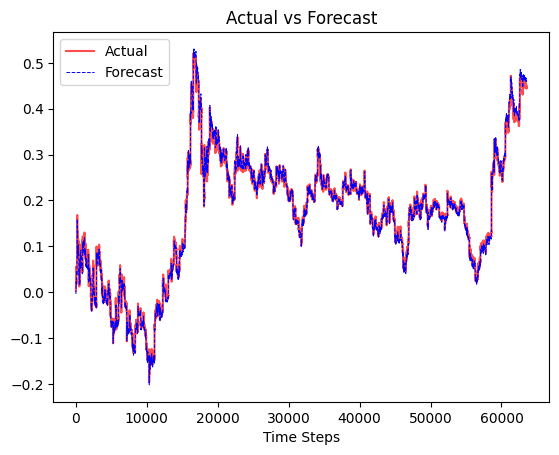

In [23]:
test_result2, truth2 = forecast_seq(model_val, val_data2)

plt.plot(truth2, color="red", alpha=0.7)
plt.plot(test_result2, color="blue", linestyle="dashed", linewidth=0.7)
plt.title("Actual vs Forecast")
plt.legend(["Actual", "Forecast"])
plt.xlabel("Time Steps")
plt.show()

### jp_morgan data

In [24]:
df3 = pd.read_csv("/content/drive/MyDrive/Colab-Notebooks/Time-Series-Forecasting/data/jp_morgan.csv")
close3 = df3["close"].fillna(method = "ffill")
close3 = np.array(close3)
logreturn3 = np.diff(np.log(close3))


/tmp/ipykernel_13684/722447245.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  close3 = df3["close"].fillna(method = "ffill")


In [26]:
train_data3, val_data3 = split_data(logreturn3, split=0.6)
test3_eval = evaluate(model_val, val_data3)
print(f'jp morgan test loss: {test3_eval :.5f}')

jp morgan test loss: 0.00004


87.48644685745239 sec


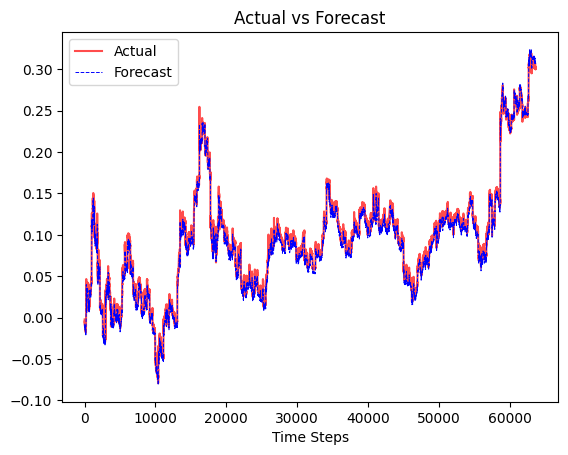

In [27]:
test_result3, truth3 = forecast_seq(model_val, val_data3)

plt.plot(truth3, color="red", alpha=0.7)
plt.plot(test_result3, color="blue", linestyle="dashed", linewidth=0.7)
plt.title("Actual vs Forecast")
plt.legend(["Actual", "Forecast"])
plt.xlabel("Time Steps")
plt.show()